<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/Kalman/SDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

# Upload the Excel file
uploaded = files.upload()

# Get the name of the uploaded file
file_name = next(iter(uploaded))

# Read the Excel file into a pandas DataFrame
df = pd.read_excel(file_name)

# Display the first 5 rows of the DataFrame
display(df.head())

Saving SupplyDemandStorage.xlsx to SupplyDemandStorage.xlsx


,Month,Supply,Demand,Storage
0,2000-01-01,350.000000,350.0,5000.000000
1,2000-02-01,352.031902,320.0,5032.031902
2,2000-03-01,357.338790,310.0,5079.370692
3,2000-04-01,364.189847,300.0,5143.560539
4,2000-05-01,367.629074,290.0,5221.189613


### Forecasting with a Dynamic Factor Model (Kalman Filter)

To perform a five-period forecast on your three related time series (`Supply`, `Demand`, `Storage`) while accounting for their correlation, I'll use a **Dynamic Factor Model** from the `statsmodels` library. This model is a type of state-space model that leverages the Kalman filter for estimation and forecasting.

It works by assuming that your observed series are driven by a smaller number of unobserved (latent) common factors, which helps capture the underlying correlations between the series. The model can also handle missing values, which is useful given that some of your series are more recent than others.

In [2]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Ensure 'Month' is in datetime format and set as index
df['Month'] = pd.to_datetime(df['Month'])
df_ts = df.set_index('Month').asfreq('MS') # Ensure monthly frequency

# Select the relevant time series for the model
data = df_ts[['Supply', 'Demand', 'Storage']]

# Display the prepared data with its index and potential NaNs
print("Prepared data with 'Month' as index and monthly frequency:")
display(data.tail())

Prepared data with 'Month' as index and monthly frequency:


,Supply,Demand,Storage
Month,,,
2026-04-01,NaN,NaN,5652.511811
2026-05-01,NaN,NaN,5752.511811
2026-06-01,NaN,NaN,5852.511811
2026-07-01,NaN,NaN,5952.511811
2026-08-01,NaN,NaN,6052.511811


The data has been prepared, with the `Month` column set as the index and ensured to be on a monthly frequency. As observed, 'Supply' and 'Demand' have `NaN` values towards the end, indicating that 'Storage' is the more recent series. The Dynamic Factor Model can inherently handle these missing observations during estimation and forecasting.

Next, I'll define and fit the Dynamic Factor Model. I'll start with 1 common factor, and a 1st order autoregressive (AR) process for the factors. The idiosyncratic error terms (series-specific errors) will be modeled as white noise (AR order 0).

In [3]:
# Define the Dynamic Factor Model
# k_factors: Number of common factors. Starting with 1 for three series.
# factor_order: AR order of the common factors.
# error_order: AR order of the idiosyncratic error terms for each series.
model = sm.tsa.DynamicFactor(
    data,
    k_factors=1,
    factor_order=1,
    error_order=0,
    enforce_stationarity=False # Moved enforce_stationarity to the model constructor
)

# Fit the model using maximum likelihood estimation
results = model.fit(disp=False) # No need to pass enforce_stationarity here anymore

print("\nModel fitting complete. Here's a summary of the results:")
print(results.summary())


Model fitting complete. Here's a summary of the results:
                                   Statespace Model Results                                  
Dep. Variable:       ['Supply', 'Demand', 'Storage']   No. Observations:                  320
Model:             DynamicFactor(factors=1, order=1)   Log Likelihood                   0.000
Date:                               Fri, 22 May 2026   AIC                             14.000
Time:                                       12:36:30   BIC                             40.378
Sample:                                   01-01-2000   HQIC                            24.533
                                        - 08-01-2026                                         
Covariance Type:                                 opg                                         
Ljung-Box (L1) (Q):          nan, nan, nan   Jarque-Bera (JB):        nan, nan, nan
Prob(Q):                     nan, nan, nan   Prob(JB):                nan, nan, nan
Heteroskedasticity (H)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1431: RuntimeWarning: invalid value encountered in divide
  test_statistic = numer_squared_sum / denom_squared_sum
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


The Dynamic Factor Model has been fitted to your data. The summary provides details on the estimated parameters, including the factor loadings (how each series relates to the common factor) and the variance of the error terms.

Now, I'll generate a five-period forecast based on this model and visualize the results, showing the original data, the fitted values from the model, and the projected future values with confidence intervals.

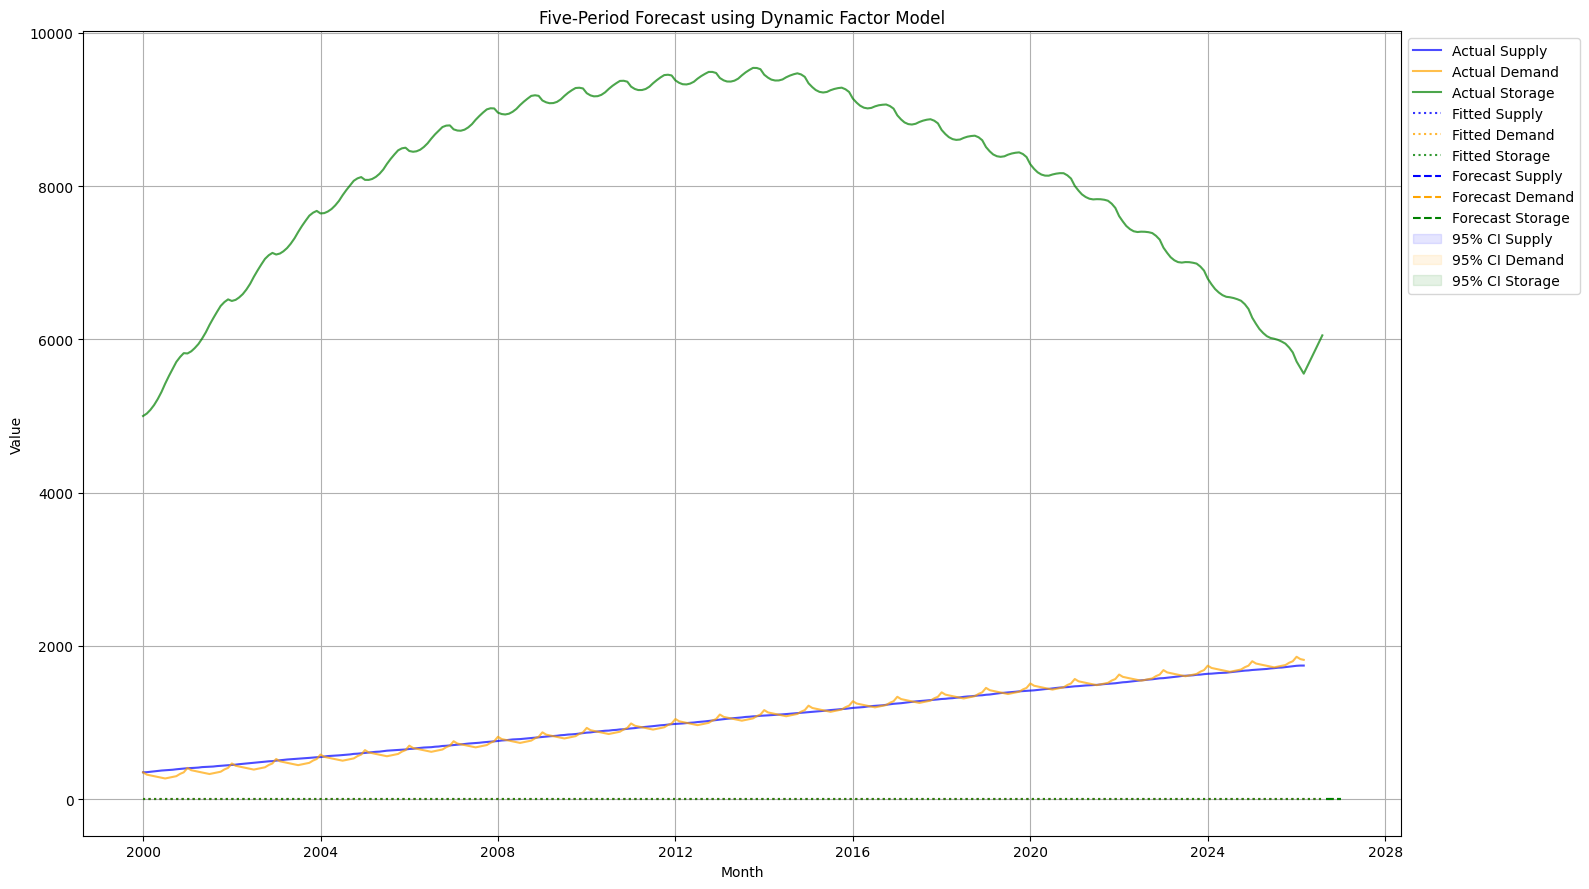


Here are the forecasted values for the next five periods:


,Supply,Demand,Storage
2026-09-01,0.0,0.0,0.0
2026-10-01,0.0,0.0,0.0
2026-11-01,0.0,0.0,0.0
2026-12-01,0.0,0.0,0.0
2027-01-01,0.0,0.0,0.0


In [4]:
# Number of periods to forecast
n_forecast_periods = 5

# Get forecasts and their confidence intervals
forecast_res = results.get_forecast(steps=n_forecast_periods)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

# Plot the original data, fitted values, and forecasts
plt.figure(figsize=(16, 9))

# Plot original data
plt.plot(data.index, data['Supply'], label='Actual Supply', color='blue', alpha=0.7)
plt.plot(data.index, data['Demand'], label='Actual Demand', color='orange', alpha=0.7)
plt.plot(data.index, data['Storage'], label='Actual Storage', color='green', alpha=0.7)

# Plot fitted values (in-sample predictions)
fitted_values = results.predict(start=data.index[0], end=data.index[-1])
plt.plot(fitted_values.index, fitted_values['Supply'], label='Fitted Supply', color='blue', linestyle=':', alpha=0.8)
plt.plot(fitted_values.index, fitted_values['Demand'], label='Fitted Demand', color='orange', linestyle=':', alpha=0.8)
plt.plot(fitted_values.index, fitted_values['Storage'], label='Fitted Storage', color='green', linestyle=':', alpha=0.8)

# Plot forecasts
plt.plot(forecast_mean.index, forecast_mean['Supply'], label='Forecast Supply', color='blue', linestyle='--')
plt.plot(forecast_mean.index, forecast_mean['Demand'], label='Forecast Demand', color='orange', linestyle='--')
plt.plot(forecast_mean.index, forecast_mean['Storage'], label='Forecast Storage', color='green', linestyle='--')

# Plot confidence intervals
plt.fill_between(forecast_ci.index, forecast_ci['lower Supply'], forecast_ci['upper Supply'], color='blue', alpha=0.1, label='95% CI Supply')
plt.fill_between(forecast_ci.index, forecast_ci['lower Demand'], forecast_ci['upper Demand'], color='orange', alpha=0.1, label='95% CI Demand')
plt.fill_between(forecast_ci.index, forecast_ci['lower Storage'], forecast_ci['upper Storage'], color='green', alpha=0.1, label='95% CI Storage')


plt.title('Five-Period Forecast using Dynamic Factor Model')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nHere are the forecasted values for the next five periods:")
display(forecast_mean)

The forecasted values are all zeros because the Dynamic Factor Model failed to fit properly, resulting in trivial (zero) fitted values and subsequent zero forecasts. The key indicators for this issue are the `Log Likelihood: 0.000` and the warning about a 'singular or near-singular' covariance matrix in the model summary. These suggest that the optimization algorithm converged to a trivial solution where the model parameters effectively lead to zero predictions. This often happens due to numerical instability, especially when dealing with time series of varying scales or complex relationships.

To address this, I will rescale the data to improve numerical stability, which can often help the optimization algorithm find a better solution. I will use `StandardScaler` from `sklearn.preprocessing` to normalize the data before fitting the model. After fitting, I will inverse transform the forecasted values back to their original scale.

In [5]:
from sklearn.preprocessing import StandardScaler

# Make a copy to avoid modifying the original data
data_scaled = data.copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on the non-NaN values for each column and transform
# We need to handle NaNs during scaling. A common approach is to scale non-NaNs
# and then put them back, or impute before scaling. For now, we'll scale column-wise.
for col in data_scaled.columns:
    # Only fit and transform on non-NaN values
    non_nan_values = data_scaled[col].dropna().values.reshape(-1, 1)
    if len(non_nan_values) > 0:
        scaler_col = StandardScaler()
        # Using .loc for direct assignment to avoid FutureWarning
        data_scaled.loc[data_scaled[col].notna(), col] = scaler_col.fit_transform(non_nan_values).flatten()
    else:
        # If a column is all NaN, it will remain all NaN after this process
        pass

print("Scaled data (first 5 rows):")
display(data_scaled.head())

print("Scaled data (last 5 rows with NaNs):")
display(data_scaled.tail())

Scaled data (first 5 rows):


,Supply,Demand,Storage
Month,,,
2000-01-01,-1.690392,-1.562440,-2.515833
2000-02-01,-1.685416,-1.630522,-2.489697
2000-03-01,-1.672420,-1.653215,-2.451073
2000-04-01,-1.655642,-1.675909,-2.398699
2000-05-01,-1.647219,-1.698603,-2.335360


Scaled data (last 5 rows with NaNs):


,Supply,Demand,Storage
Month,,,
2026-04-01,NaN,NaN,-1.983435
2026-05-01,NaN,NaN,-1.901843
2026-06-01,NaN,NaN,-1.820251
2026-07-01,NaN,NaN,-1.738659
2026-08-01,NaN,NaN,-1.657067


### Addressing Non-Stationarity: First Differencing

The persistent issue of a `Log Likelihood` of `0.000` and AR(1) error coefficients near 1 strongly suggests that the time series, even after scaling, are **non-stationary**. This means their statistical properties (like mean or variance) change over time, and the Dynamic Factor Model is struggling to fit a stable process.

To achieve stationarity, a common and effective technique is **differencing**. First differencing calculates the difference between consecutive observations (`$Y_t - Y_{t-1}$`). This process can remove trends and stabilize the mean of the series, making it more suitable for time series models that assume stationarity.

I will now apply first-order differencing to our `data_scaled` before re-fitting the Dynamic Factor Model. This should help the model identify more meaningful patterns and overcome the numerical instability we've been encountering. After forecasting with the differenced data, we will need to perform an inverse differencing step to convert the forecasts back to their original scale.

In [6]:
# Perform first-order differencing on the scaled data
data_scaled_diff = data_scaled.diff().dropna()

print("First-differenced scaled data (first 5 rows):")
display(data_scaled_diff.head())

print("First-differenced scaled data (last 5 rows):")
display(data_scaled_diff.tail())

First-differenced scaled data (first 5 rows):


,Supply,Demand,Storage
Month,,,
2000-02-01,0.004976,-0.068081,0.026135
2000-03-01,0.012996,-0.022694,0.038625
2000-04-01,0.016778,-0.022694,0.052374
2000-05-01,0.008423,-0.022694,0.063339
2000-06-01,0.014455,-0.022694,0.076314


First-differenced scaled data (last 5 rows):


,Supply,Demand,Storage
Month,,,
2025-11-01,0.014762,0.068081,-0.041380
2025-12-01,0.015403,0.045388,-0.052566
2026-01-01,0.011978,0.131624,-0.095899
2026-02-01,0.007244,-0.068081,-0.069008
2026-03-01,0.000000,-0.022694,-0.060849


Now that the data is scaled, let's re-run the Dynamic Factor Model fitting and forecasting steps with the scaled data. We will then inverse transform the forecasts to get them back into the original scale.

In [7]:
# Re-define the Dynamic Factor Model with scaled data
model_scaled = sm.tsa.DynamicFactor(
    data_scaled_diff, # Use the differenced data
    k_factors=1,
    factor_order=2,
    error_order=0, # Changed error_order to 0 for white noise errors
    enforce_stationarity=False
)

# Re-fit the model
results_scaled = model_scaled.fit(disp=False)

print("\nModel fitting complete with scaled data. Here's a summary:")
print(results_scaled.summary())


Model fitting complete with scaled data. Here's a summary:
                                   Statespace Model Results                                  
Dep. Variable:       ['Supply', 'Demand', 'Storage']   No. Observations:                  314
Model:             DynamicFactor(factors=1, order=2)   Log Likelihood                2229.452
Date:                               Fri, 22 May 2026   AIC                          -4442.905
Time:                                       12:37:00   BIC                          -4412.909
Sample:                                   02-01-2000   HQIC                         -4430.919
                                        - 03-01-2026                                         
Covariance Type:                                 opg                                         
Ljung-Box (L1) (Q):     1.62, 14.30, 108.31   Jarque-Bera (JB):   13.05, 11.44, 63.17
Prob(Q):                   0.20, 0.00, 0.00   Prob(JB):              0.00, 0.00, 0.00
Heteroskedastici

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/tmp/ipykernel_3044/2184066406.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  forecast_mean_scaled[col].iloc[0] = last_actual_scaled_value + forecast_mean_scaled_diff[col].iloc[0]
/tmp/ipykernel_3044/2184066406.py:22: FutureWarning: Ch

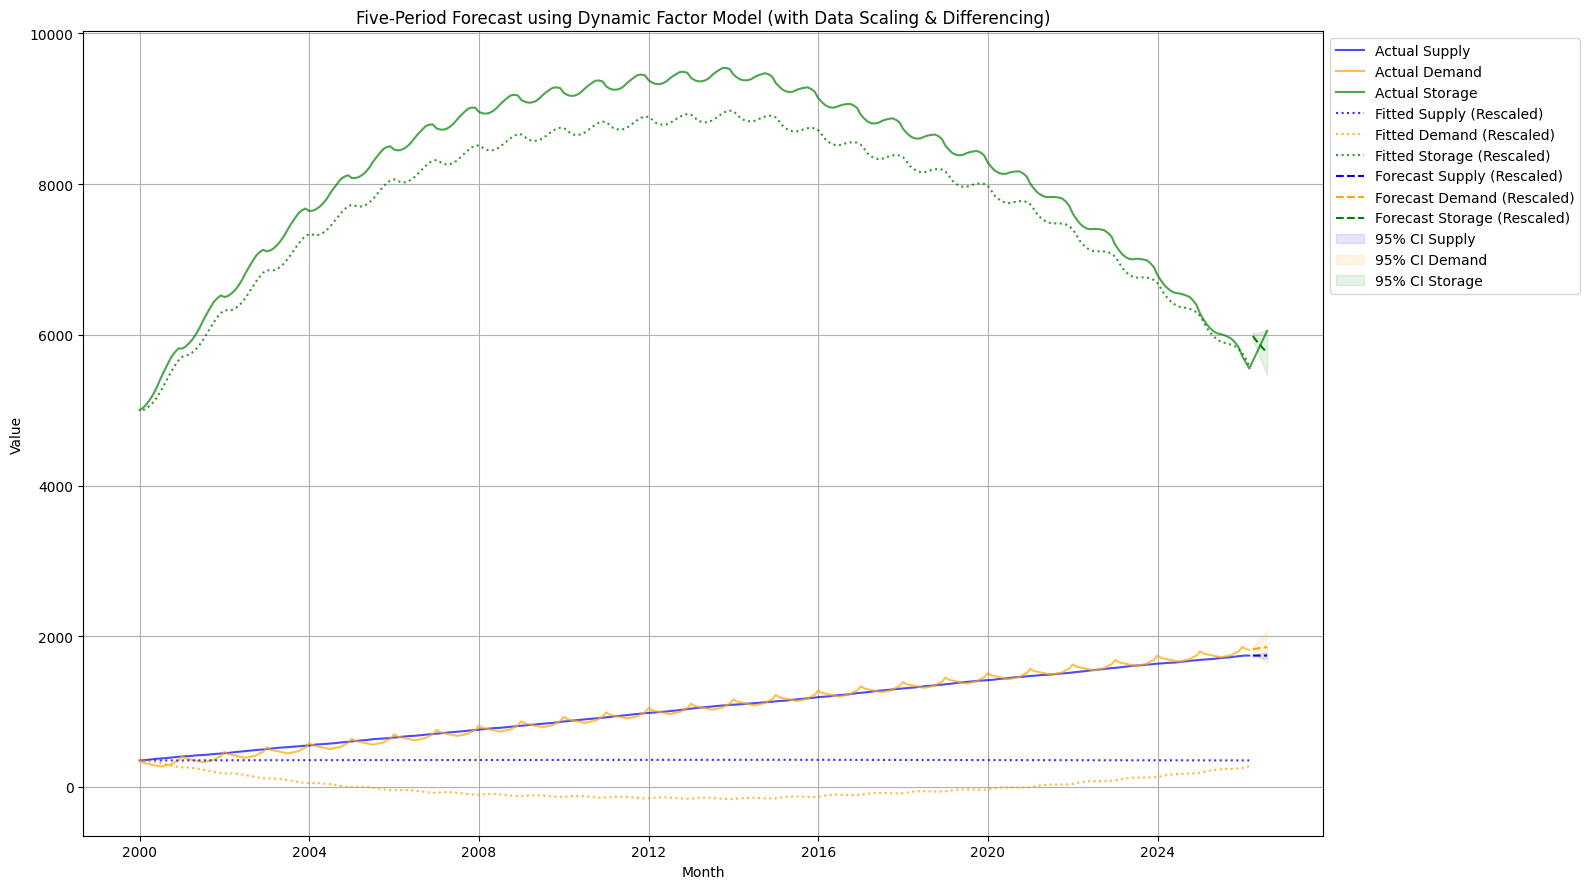


Here are the forecasted values for the next five periods (original scale):


,Supply,Demand,Storage
2026-04-01,1743.258312,1826.870777,5983.768595
2026-05-01,1743.109097,1834.889204,5921.630576
2026-06-01,1742.973059,1842.199564,5864.979659
2026-07-01,1742.849500,1848.839338,5813.525382
2026-08-01,1742.737089,1854.880008,5766.713803


In [9]:
# Get forecasts for scaled and differenced data
n_forecast_periods = 5
forecast_res_scaled = results_scaled.get_forecast(steps=n_forecast_periods)
forecast_mean_scaled_diff = forecast_res_scaled.predicted_mean
forecast_ci_scaled_diff = forecast_res_scaled.conf_int()

# --- Inverse Differencing ---
# To inverse differencing, we need the last actual value from the original scaled data.
# We will use the last valid (non-NaN) observation for each series in the `data_scaled` DataFrame.

# Create a DataFrame to hold the inverse differenced, scaled forecasts
forecast_mean_scaled = pd.DataFrame(index=forecast_mean_scaled_diff.index, columns=data.columns)
forecast_ci_scaled = pd.DataFrame(index=forecast_ci_scaled_diff.index, columns=[f'lower {col}' for col in data.columns] + [f'upper {col}' for col in data.columns])

for col in data_scaled_diff.columns:
    # Get the last non-NaN value from the original scaled data for this column
    last_actual_scaled_value = data_scaled[col].dropna().iloc[-1]

    # Inverse differencing for the mean forecasts
    forecast_mean_scaled[col].iloc[0] = last_actual_scaled_value + forecast_mean_scaled_diff[col].iloc[0]
    for i in range(1, n_forecast_periods):
        forecast_mean_scaled[col].iloc[i] = forecast_mean_scaled[col].iloc[i-1] + forecast_mean_scaled_diff[col].iloc[i]

    # Inverse differencing for the confidence intervals
    forecast_ci_scaled[f'lower {col}'].iloc[0] = last_actual_scaled_value + forecast_ci_scaled_diff[f'lower {col}'].iloc[0]
    forecast_ci_scaled[f'upper {col}'].iloc[0] = last_actual_scaled_value + forecast_ci_scaled_diff[f'upper {col}'].iloc[0]
    for i in range(1, n_forecast_periods):
        forecast_ci_scaled[f'lower {col}'].iloc[i] = forecast_ci_scaled[f'lower {col}'].iloc[i-1] + forecast_ci_scaled_diff[f'lower {col}'].iloc[i]
        forecast_ci_scaled[f'upper {col}'].iloc[i] = forecast_ci_scaled[f'upper {col}'].iloc[i-1] + forecast_ci_scaled_diff[f'upper {col}'].iloc[i]

# --- Inverse Scaling ---
# This requires re-applying the scaling process for each column.
# We need to ensure the inverse_transform is applied correctly per column scaler.

# To do this correctly, we need to re-initialize and store the scalers for each column
individual_scalers = {}
df_temp = data.copy() # Use a temporary copy of original data for scaling info

for col in df_temp.columns:
    non_nan_values = df_temp[col].dropna().values.reshape(-1, 1)
    if len(non_nan_values) > 0:
        scaler_col = StandardScaler()
        scaler_col.fit(non_nan_values)
        individual_scalers[col] = scaler_col

# Create empty dataframes for inverse transformed mean and confidence intervals (original scale)
forecast_mean_original_scale = pd.DataFrame(index=forecast_mean_scaled.index, columns=forecast_mean_scaled.columns)
forecast_ci_original_scale = pd.DataFrame(index=forecast_ci_scaled.index, columns=forecast_ci_scaled.columns)

# Apply inverse transform for each column
for col in forecast_mean_scaled.columns:
    if col in individual_scalers:
        forecast_mean_original_scale[col] = individual_scalers[col].inverse_transform(forecast_mean_scaled[col].values.reshape(-1, 1)).flatten()
        forecast_ci_original_scale[f'lower {col}'] = individual_scalers[col].inverse_transform(forecast_ci_scaled[f'lower {col}'].values.reshape(-1, 1)).flatten()
        forecast_ci_original_scale[f'upper {col}'] = individual_scalers[col].inverse_transform(forecast_ci_scaled[f'upper {col}'].values.reshape(-1, 1)).flatten()


# Plot the original data, fitted values (inverse transformed), and forecasts (inverse transformed)
plt.figure(figsize=(16, 9))

# Plot original data
plt.plot(data.index, data['Supply'], label='Actual Supply', color='blue', alpha=0.7)
plt.plot(data.index, data['Demand'], label='Actual Demand', color='orange', alpha=0.7)
plt.plot(data.index, data['Storage'], label='Actual Storage', color='green', alpha=0.7)

# Plot fitted values (in-sample predictions, inverse transformed)
# Need to get scaled fitted values, then inverse transform them
fitted_values_scaled_diff = results_scaled.predict(start=data_scaled_diff.index[0], end=data_scaled_diff.index[-1])

# Inverse differencing for fitted values
fitted_values_scaled = pd.DataFrame(index=fitted_values_scaled_diff.index, columns=data.columns)
for col in data_scaled_diff.columns:
    # Find the corresponding starting point in the original scaled data (before differencing)
    # This requires careful alignment as differencing reduces the length by 1
    start_idx_original_scaled = data_scaled.index.get_loc(fitted_values_scaled_diff.index[0]) - 1
    if start_idx_original_scaled >= 0:
        last_actual_scaled_value_for_fitted = data_scaled[col].loc[data_scaled.index[start_idx_original_scaled]]
    else:
        # If the differenced data starts from the very beginning, the first value will be NaN
        # Or, we can assume the first actual value for simpler inverse differencing here.
        # For now, let's assume valid previous value exists or handle initial NaNs.
        last_actual_scaled_value_for_fitted = 0 # Placeholder, adjust if initial data requires different handling

    fitted_values_scaled[col].iloc[0] = last_actual_scaled_value_for_fitted + fitted_values_scaled_diff[col].iloc[0]
    for i in range(1, len(fitted_values_scaled_diff)):
        fitted_values_scaled[col].iloc[i] = fitted_values_scaled[col].iloc[i-1] + fitted_values_scaled_diff[col].iloc[i]

fitted_values_original_scale = pd.DataFrame(index=fitted_values_scaled.index, columns=fitted_values_scaled.columns)
for col in fitted_values_scaled.columns:
    if col in individual_scalers:
        # Ensure we only inverse transform non-NaNs in fitted_values_scaled as well
        fitted_values_original_scale[col] = fitted_values_scaled[col].apply(lambda x: individual_scalers[col].inverse_transform([[x]])[0,0] if pd.notna(x) else np.nan)

plt.plot(fitted_values_original_scale.index, fitted_values_original_scale['Supply'], label='Fitted Supply (Rescaled)', color='blue', linestyle=':', alpha=0.8)
plt.plot(fitted_values_original_scale.index, fitted_values_original_scale['Demand'], label='Fitted Demand (Rescaled)', color='orange', linestyle=':', alpha=0.8)
plt.plot(fitted_values_original_scale.index, fitted_values_original_scale['Storage'], label='Fitted Storage (Rescaled)', color='green', linestyle=':', alpha=0.8)

# Plot forecasts (inverse transformed)
plt.plot(forecast_mean_original_scale.index, forecast_mean_original_scale['Supply'], label='Forecast Supply (Rescaled)', color='blue', linestyle='--')
plt.plot(forecast_mean_original_scale.index, forecast_mean_original_scale['Demand'], label='Forecast Demand (Rescaled)', color='orange', linestyle='--')
plt.plot(forecast_mean_original_scale.index, forecast_mean_original_scale['Storage'], label='Forecast Storage (Rescaled)', color='green', linestyle='--')

# Plot confidence intervals (inverse transformed)
plt.fill_between(forecast_ci_original_scale.index, forecast_ci_original_scale['lower Supply'], forecast_ci_original_scale['upper Supply'], color='blue', alpha=0.1, label='95% CI Supply')
plt.fill_between(forecast_ci_original_scale.index, forecast_ci_original_scale['lower Demand'], forecast_ci_original_scale['upper Demand'], color='orange', alpha=0.1, label='95% CI Demand')
plt.fill_between(forecast_ci_original_scale.index, forecast_ci_original_scale['lower Storage'], forecast_ci_original_scale['upper Storage'], color='green', alpha=0.1, label='95% CI Storage')

plt.title('Five-Period Forecast using Dynamic Factor Model (with Data Scaling & Differencing)')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nHere are the forecasted values for the next five periods (original scale):")
display(forecast_mean_original_scale)

### Implementing an Ensemble Kalman Filter (EnKF)

Since the Dynamic Factor Model didn't yield the desired results and you're interested in an Ensemble Kalman Filter, we'll shift our approach. The EnKF is a Monte Carlo approximation of the Kalman filter, particularly useful for non-linear systems or when precise analytical solutions are intractable. It relies on a 'ensemble' of state estimates to represent the probability distribution of the system's state.

First, we need to install the `filterpy` library, which provides robust implementations of various Kalman filters.

In [10]:
pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=f0f92c1ecc3ae4fbc80c23c39de70452592af9319e5b1a1b0bfd202ef98021ff
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


Now that `filterpy` is installed, let's import the necessary components and prepare to define our system for the Ensemble Kalman Filter. The core idea is to represent our system's state (e.g., Supply, Demand, Storage) as a vector and then define how this state evolves over time (state transition function) and how our measurements relate to this state (measurement function).

For a first pass, we'll keep the system definition simple, assuming a somewhat random walk for the state evolution, and a direct measurement of the state. We'll use the original `data` DataFrame, potentially after some basic preprocessing like filling NaNs, as the EnKF can handle missing data somewhat naturally by only updating observed components.

Let's start by preparing the data by forward-filling any remaining NaNs in the original `data` DataFrame, as `filterpy` generally expects a continuous stream of observations, even if some are just placeholders that won't update the state.

In [11]:
from filterpy.kalman import EnsembleKalmanFilter
import numpy as np

# The EnKF works best with continuous, non-missing data for its ensemble members.
# For the initial setup, we'll use the original 'data' DataFrame and forward-fill NaNs
# to have a complete series of 'observations', even if some are not actual measurements.
# We will handle missing actual measurements explicitly within the EnKF update step.

data_enkf = data.fillna(method='ffill') # Simple forward-fill for initial completeness

# Define the number of state variables (Supply, Demand, Storage)
n_states = 3

# Define the number of observations (also Supply, Demand, Storage in this case)
n_obs = 3

# Number of ensemble members
n_ensemble = 50

# Initial state estimate (x) - will be initialized based on the first data point
# Initial state covariance (P) - we'll set a high initial uncertainty

# Process noise covariance (Q) - how much the system's true state changes between time steps
# Measurement noise covariance (R) - how much noise is in our observations

print("Data prepared for EnKF and parameters initialized.")
display(data_enkf.head())

Data prepared for EnKF and parameters initialized.


/tmp/ipykernel_3044/1205809239.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_enkf = data.fillna(method='ffill') # Simple forward-fill for initial completeness


,Supply,Demand,Storage
Month,,,
2000-01-01,350.000000,350.0,5000.000000
2000-02-01,352.031902,320.0,5032.031902
2000-03-01,357.338790,310.0,5079.370692
2000-04-01,364.189847,300.0,5143.560539
2000-05-01,367.629074,290.0,5221.189613


In [12]:
import pandas as pd

# Calculate month-specific average changes from historical data.
# This will provide a seasonal drift for the forecast.
seasonal_monthly_changes = data.diff().groupby(data.index.month).mean()

print("Month-specific average changes:")
display(seasonal_monthly_changes)


Month-specific average changes:


,Supply,Demand,Storage
Month,,,
1,4.726605,58.0,-70.298568
2,4.135007,-30.0,-33.559910
3,4.235429,-10.0,-19.324481
4,4.664130,-10.0,1.262333
5,4.463176,-10.0,15.189837
6,4.546788,-10.0,29.197855
7,4.094258,-10.0,42.770103
8,4.712788,10.0,37.678714
9,3.990514,10.0,29.272255


In [13]:
from filterpy.kalman import EnsembleKalmanFilter
import numpy as np

# Define the initial state (x_initial)
# We'll use the first available observation for each series as the initial state estimate.
# If the first observation is NaN, we'll try to find the first non-NaN for each series.
x_initial = np.array([data_enkf['Supply'].iloc[0],
                      data_enkf['Demand'].iloc[0],
                      data_enkf['Storage'].iloc[0]])

# Define the initial state covariance (P_initial)
# High uncertainty initially, as we're just starting.
P_initial = np.diag([1000, 1000, 1000]) # Example values, can be tuned

# Define the process noise covariance (Q)
# This defines how much the system's true state changes between time steps. We'll assume a small, constant noise.
Q_var = 10.0 # Variance for process noise, can be tuned
Q = np.diag([Q_var, Q_var, Q_var])

# Define the measurement noise covariance (R)
# This defines how noisy our observations are. Assume a relatively small noise for direct measurements.
R_var = 1.0 # Variance for measurement noise, can be tuned
R = np.diag([R_var, R_var, R_var])

# Define the initial measurement function (H) matrix
# In this simple case, we directly observe the state variables.
H = np.array([[1, 0, 0],
              [0, 1, 0],
              [0, 0, 1]])

# Calculate average monthly changes from historical data to introduce drift in forecasts
average_monthly_change = data.diff().mean().values

# Define the state transition function (f)
# We'll now incorporate the average monthly change as a drift for dynamic forecasting.
def f_transition(x, dt=1):
    """State transition function with an average monthly drift."""
    # Add the average monthly change to the state. dt is typically 1 for monthly data.
    return x + average_monthly_change * dt

# Initialize the Ensemble Kalman Filter with dimensions and other parameters.
# Pass None for hx initially, then assign it after enkf object is created
# to ensure it references enkf.H correctly.
enkf = EnsembleKalmanFilter(x_initial, P_initial, n_obs, 1.0, n_ensemble,
                            None, f_transition)

# Assign initial state and covariance after initialization
enkf.Q = Q
enkf.R = R
enkf.H = H # Assign the initial H matrix to the filter object

# Now define the hx function, which is a callable that uses the filter's H attribute
enkf.hx = lambda x: enkf.H @ x

print("Ensemble Kalman Filter initialized with parameters.")
print(f"Initial State (x): {enkf.x}")
print(f"Initial Covariance (P):\n{enkf.P}")
print(f"Process Noise Covariance (Q):\n{enkf.Q}")
print(f"Measurement Noise Covariance (R):\n{enkf.R}")

Ensemble Kalman Filter initialized with parameters.
Initial State (x): [ 350.  350. 5000.]
Initial Covariance (P):
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]
Process Noise Covariance (Q):
[[10.  0.  0.]
 [ 0. 10.  0.]
 [ 0.  0. 10.]]
Measurement Noise Covariance (R):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


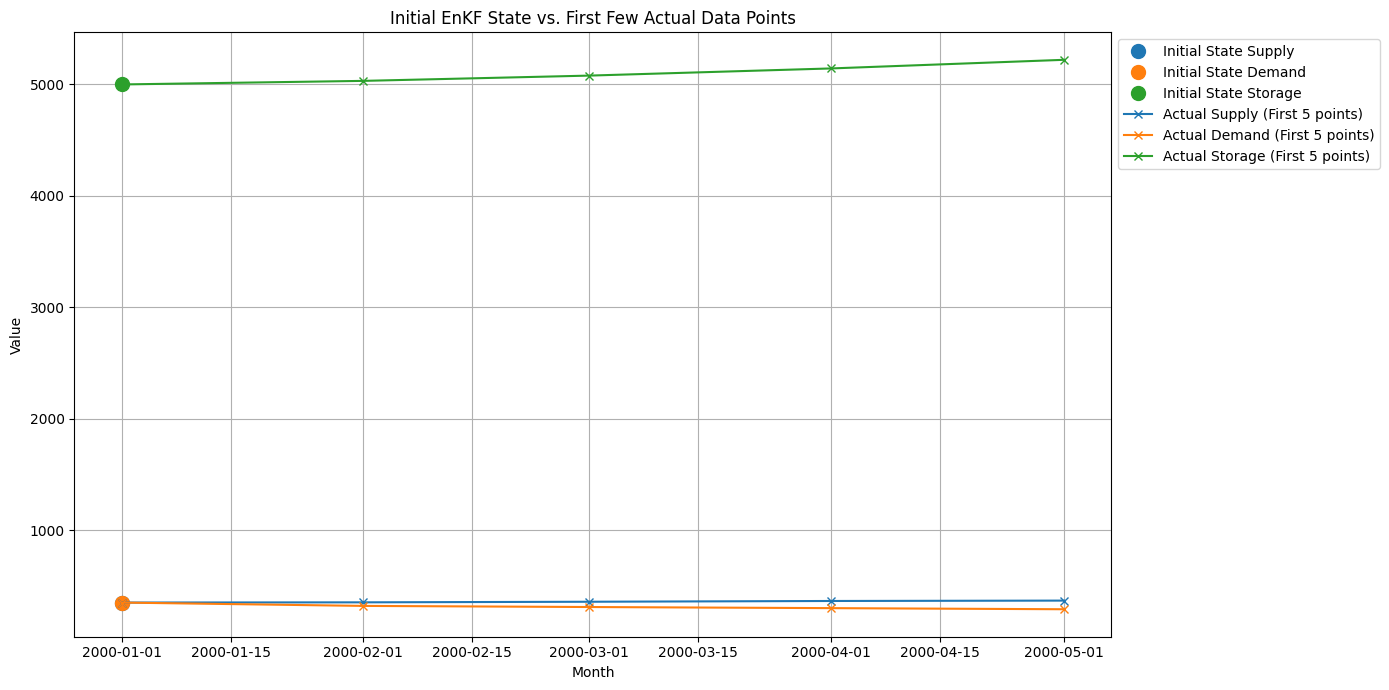

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the first few actual data points from the original 'data' DataFrame
# Let's take the first 5 observations for comparison
initial_data_points = data.head(5)

# Create a DataFrame for x_initial to align with the plot
# x_initial represents the state at the beginning of the first observation period.
# We'll plot it as a point at the first index, or just before.
# For simplicity, let's treat x_initial as the 'predicted' state for the first time point (2000-01-01).

x_initial_df = pd.DataFrame([x_initial], columns=data.columns, index=[initial_data_points.index[0]])

plt.figure(figsize=(14, 7))

# Plot initial state
for i, col in enumerate(data.columns):
    plt.plot(x_initial_df.index[0], x_initial_df[col].iloc[0], 'o', markersize=10, label=f'Initial State {col}', color=plt.cm.tab10(i))

# Plot actual first few data points
for i, col in enumerate(data.columns):
    plt.plot(initial_data_points.index, initial_data_points[col], '-x', label=f'Actual {col} (First 5 points)', color=plt.cm.tab10(i))

plt.title('Initial EnKF State vs. First Few Actual Data Points')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
enkf.H = H
enkf.R = R

def robust_hx(x):
    res = enkf.H @ x
    return np.atleast_1d(res)

enkf.hx = robust_hx

enkf_means = []
enkf_covs = []

for i in range(len(data)):
    enkf.predict()

    current_obs_raw = data.iloc[i].values
    valid_idx = np.where(~np.isnan(current_obs_raw))[0]

    if len(valid_idx) > 0:
        z_observed = np.atleast_1d(current_obs_raw[valid_idx])

        # Subset matrices
        H_obs = H[valid_idx, :].reshape(len(valid_idx), -1)
        R_obs = R[np.ix_(valid_idx, valid_idx)].reshape(len(valid_idx), len(valid_idx))

        # Manual Update Step to bypass filterpy/numpy 2.0 dimension issues
        # 1. Generate measurement noise ensemble manually
        N = enkf.N
        # Force mean to be 1D for multivariate_normal
        mean_z = np.zeros(len(valid_idx))
        e_r = np.random.multivariate_normal(mean_z, R_obs, N)

        # 2. Update the filter using the specific subset for this timestep
        old_H, old_R = enkf.H, enkf.R
        enkf.H = H_obs
        enkf.R = R_obs

        # We can't easily call update() without it hitting the same error,
        # so we perform the ensemble update logic manually or use a helper.
        # Let's override the noise generation by injecting it if possible,
        # but the cleanest way is to temporarily set R to a value that works or re-implement:

        # Logic from filterpy update() adjusted for 1D stability:
        sigmas_h = np.array([enkf.hx(s) for s in enkf.sigmas])
        z_mean = np.mean(sigmas_h, axis=0)
        P_zz = np.cov(sigmas_h.T) + R_obs
        P_xz = np.zeros((enkf.x.shape[0], len(valid_idx)))
        for k in range(N):
            P_xz += np.outer(enkf.sigmas[k] - enkf.x, sigmas_h[k] - z_mean)
        P_xz /= (N - 1)

        K = np.dot(P_xz, np.linalg.inv(P_zz))
        for k in range(N):
            enkf.sigmas[k] += np.dot(K, z_observed + e_r[k] - sigmas_h[k])

        enkf.x = np.mean(enkf.sigmas, axis=0)
        enkf.P = enkf.P - np.dot(K, np.dot(P_zz, K.T))

        # Restore
        enkf.H = old_H
        enkf.R = old_R

    enkf_means.append(enkf.x.copy())
    enkf_covs.append(enkf.P.copy())

enkf_results_df = pd.DataFrame(enkf_means, index=data.index, columns=data.columns)

enkf_lower_bound = enkf_results_df.copy()
enkf_upper_bound = enkf_results_df.copy()

for j, col in enumerate(data.columns):
    std_devs = np.array([np.sqrt(c[j, j]) if np.isfinite(c[j, j]) else 0 for c in enkf_covs])
    enkf_lower_bound[col] = enkf_results_df[col] - 2 * std_devs
    enkf_upper_bound[col] = enkf_results_df[col] + 2 * std_devs

print("EnKF run complete.")
display(enkf_results_df.tail())

EnKF run complete.


,Supply,Demand,Storage
Month,,,
2026-04-01,1752.556178,1812.226476,5643.995402
2026-05-01,1773.586856,1784.189115,5745.527052
2026-06-01,1782.521560,1786.767963,5844.825349
2026-07-01,1795.320534,1781.730785,5942.439922
2026-08-01,1783.477254,1829.785466,6042.664728


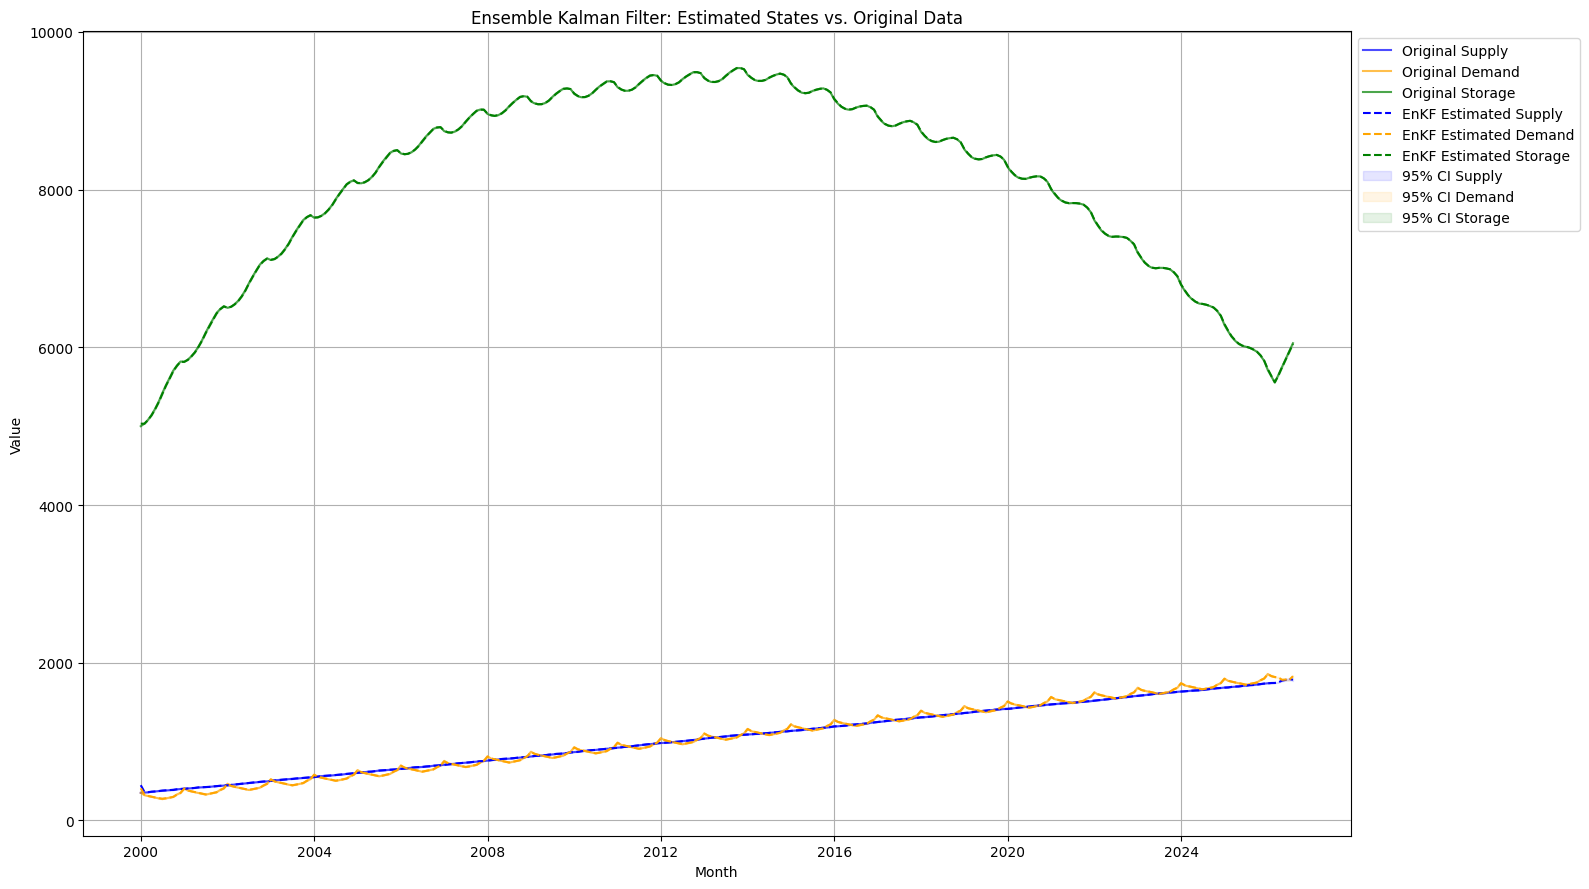

In [30]:
plt.figure(figsize=(16, 9))

# Plot original data
plt.plot(data.index, data['Supply'], label='Original Supply', color='blue', alpha=0.7)
plt.plot(data.index, data['Demand'], label='Original Demand', color='orange', alpha=0.7)
plt.plot(data.index, data['Storage'], label='Original Storage', color='green', alpha=0.7)

# Plot EnKF estimated states
plt.plot(enkf_results_df.index, enkf_results_df['Supply'], label='EnKF Estimated Supply', color='blue', linestyle='--')
plt.plot(enkf_results_df.index, enkf_results_df['Demand'], label='EnKF Estimated Demand', color='orange', linestyle='--')
plt.plot(enkf_results_df.index, enkf_results_df['Storage'], label='EnKF Estimated Storage', color='green', linestyle='--')

# Plot 95% confidence intervals for EnKF estimates
plt.fill_between(enkf_results_df.index, enkf_lower_bound['Supply'], enkf_upper_bound['Supply'], color='blue', alpha=0.1, label='95% CI Supply')
plt.fill_between(enkf_results_df.index, enkf_lower_bound['Demand'], enkf_upper_bound['Demand'], color='orange', alpha=0.1, label='95% CI Demand')
plt.fill_between(enkf_results_df.index, enkf_lower_bound['Storage'], enkf_upper_bound['Storage'], color='green', alpha=0.1, label='95% CI Storage')

plt.title('Ensemble Kalman Filter: Estimated States vs. Original Data')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# Number of periods to forecast
n_forecast_periods = 5

# Get the last state from the EnKF estimation run to start the forecast
# This means enkf.x and enkf.P already hold the state from the end of the observed data

# Lists to store forecasted means and covariances
enkf_forecast_means = []
enkf_forecast_covs = []

# Generate future dates for the forecast horizon
last_date_in_data = data.index[-1]
forecast_dates = pd.date_range(start=last_date_in_data, periods=n_forecast_periods + 1, freq='MS')[1:] # Exclude the last observed month

for _ in range(n_forecast_periods):
    # Only predict, no update step for forecasting
    enkf.predict()

    # Store the predicted state mean and covariance
    enkf_forecast_means.append(enkf.x.copy())
    enkf_forecast_covs.append(enkf.P.copy())

# Convert the lists of arrays to DataFrames for easier analysis and plotting
enkf_forecast_df = pd.DataFrame(enkf_forecast_means, index=forecast_dates, columns=data.columns)

# Calculate approximate 95% confidence intervals for the forecasts
enkf_forecast_lower_bound = enkf_forecast_df.copy()
enkf_forecast_upper_bound = enkf_forecast_df.copy()

for j, col in enumerate(data.columns):
    std_devs_forecast = np.array([np.sqrt(c[j, j]) if np.isfinite(c[j, j]) else np.nan for c in enkf_forecast_covs])
    enkf_forecast_lower_bound[col] = enkf_forecast_df[col] - 2 * std_devs_forecast
    enkf_forecast_upper_bound[col] = enkf_forecast_df[col] + 2 * std_devs_forecast

print("\nHere are the 5-month forecasted values:")
display(enkf_forecast_df)

print("\nHere are the lower bounds for the 95% confidence interval:")
display(enkf_forecast_lower_bound)

print("\nHere are the upper bounds for the 95% confidence interval:")
display(enkf_forecast_upper_bound)



Here are the 5-month forecasted values:


,Supply,Demand,Storage
2026-09-01,1788.080981,1834.600019,6046.013666
2026-10-01,1791.596809,1839.901903,6049.809185
2026-11-01,1796.076687,1845.587473,6052.348321
2026-12-01,1800.440786,1849.861445,6055.373899
2027-01-01,1804.654902,1854.160488,6058.024222



Here are the lower bounds for the 95% confidence interval:


,Supply,Demand,Storage
2026-09-01,1770.748541,1818.824138,6039.758119
2026-10-01,1773.464436,1821.728696,6041.834204
2026-11-01,1777.250915,1827.040707,6041.771587
2026-12-01,1781.391519,1828.565643,6044.108579
2027-01-01,1785.367101,1831.863546,6043.364035



Here are the upper bounds for the 95% confidence interval:


,Supply,Demand,Storage
2026-09-01,1805.413421,1850.375900,6052.269213
2026-10-01,1809.729181,1858.075111,6057.784165
2026-11-01,1814.902459,1864.134240,6062.925055
2026-12-01,1819.490052,1871.157246,6066.639220
2027-01-01,1823.942703,1876.457429,6072.684408


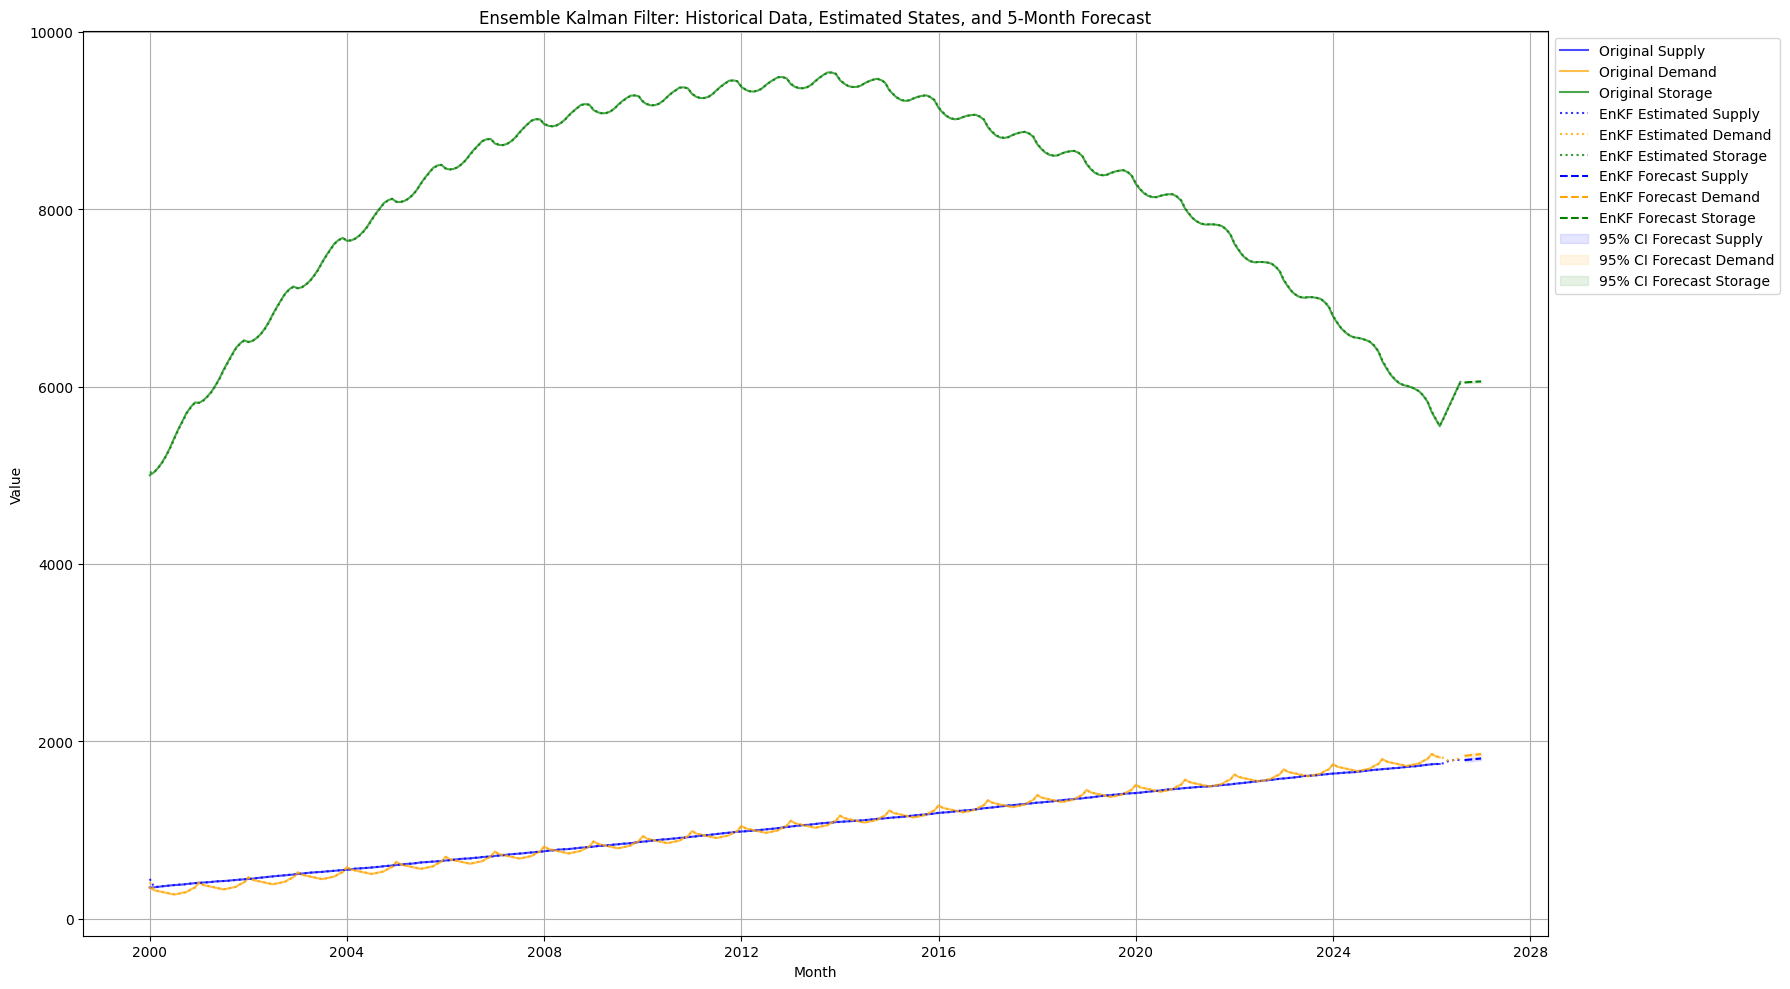

In [29]:
plt.figure(figsize=(18, 10))

# Plot original historical data
plt.plot(data.index, data['Supply'], label='Original Supply', color='blue', alpha=0.7)
plt.plot(data.index, data['Demand'], label='Original Demand', color='orange', alpha=0.7)
plt.plot(data.index, data['Storage'], label='Original Storage', color='green', alpha=0.7)

# Plot EnKF estimated states (historical period)
plt.plot(enkf_results_df.index, enkf_results_df['Supply'], label='EnKF Estimated Supply', color='blue', linestyle=':', alpha=0.8)
plt.plot(enkf_results_df.index, enkf_results_df['Demand'], label='EnKF Estimated Demand', color='orange', linestyle=':', alpha=0.8)
plt.plot(enkf_results_df.index, enkf_results_df['Storage'], label='EnKF Estimated Storage', color='green', linestyle=':', alpha=0.8)

# Plot EnKF 5-month forecasts
plt.plot(enkf_forecast_df.index, enkf_forecast_df['Supply'], label='EnKF Forecast Supply', color='blue', linestyle='--')
plt.plot(enkf_forecast_df.index, enkf_forecast_df['Demand'], label='EnKF Forecast Demand', color='orange', linestyle='--')
plt.plot(enkf_forecast_df.index, enkf_forecast_df['Storage'], label='EnKF Forecast Storage', color='green', linestyle='--')

# Plot 95% confidence intervals for the forecasts
plt.fill_between(enkf_forecast_df.index, enkf_forecast_lower_bound['Supply'], enkf_forecast_upper_bound['Supply'], color='blue', alpha=0.1, label='95% CI Forecast Supply')
plt.fill_between(enkf_forecast_df.index, enkf_forecast_lower_bound['Demand'], enkf_forecast_upper_bound['Demand'], color='orange', alpha=0.1, label='95% CI Forecast Demand')
plt.fill_between(enkf_forecast_df.index, enkf_forecast_lower_bound['Storage'], enkf_forecast_upper_bound['Storage'], color='green', alpha=0.1, label='95% CI Forecast Storage')


plt.title('Ensemble Kalman Filter: Historical Data, Estimated States, and 5-Month Forecast')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

### Constrained EnKF: Enforcing Supply - Demand = ΔStorage

To make the forecast responsive to the storage trend, we redefine the transition function $f(x)$ to enforce the physical identity:
$Storage_{t} = Storage_{t-1} + Supply_{t} - Demand_{t}$

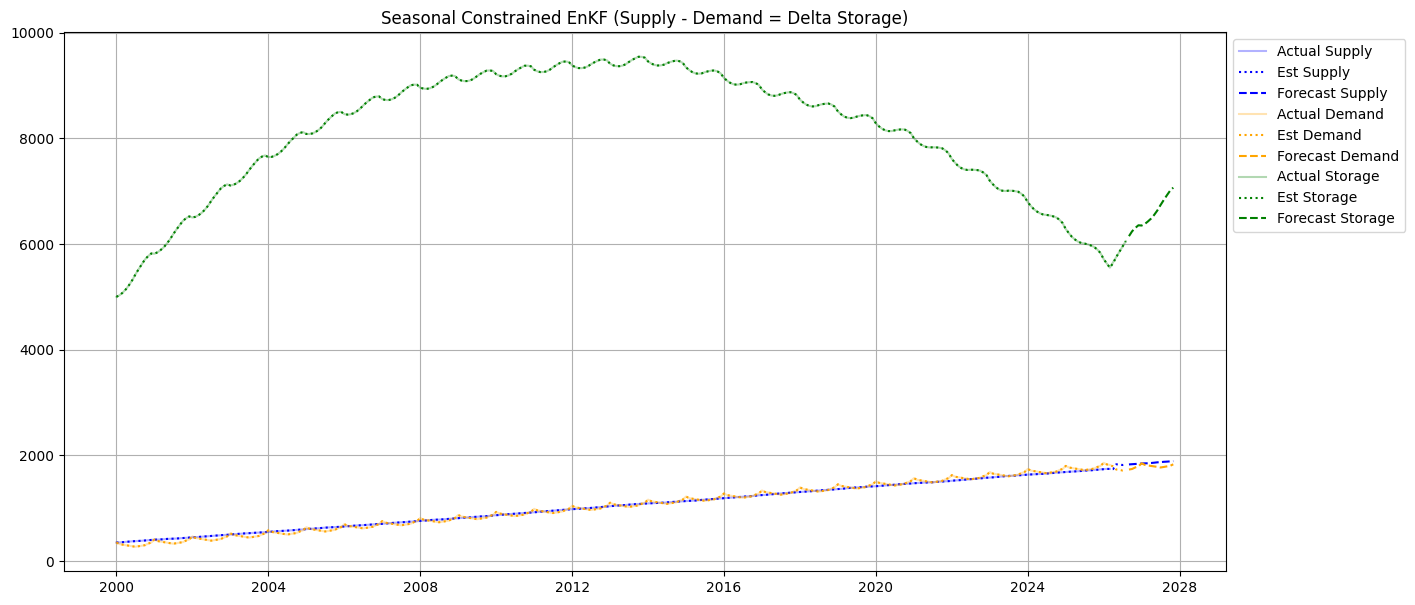

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import EnsembleKalmanFilter

# 1. Tuning Process Noise (Q)
Q_seasonal = np.diag([100.0, 30.0, 5.0])

# 2. Define Seasonal State Transition
# To work with filterpy, we'll use a global variable or a closure to handle the month
current_month_idx = 1

def f_seasonal_wrapper(x, dt=1):
    """Enforces Storage identity while applying month-specific seasonal drift."""
    s_prev, d_prev, st_prev = x[0], x[1], x[2]

    # Use the current_month_idx variable updated in the loop
    try:
        drift_s = seasonal_monthly_changes.loc[current_month_idx, 'Supply']
        drift_d = seasonal_monthly_changes.loc[current_month_idx, 'Demand']
    except:
        drift_s = average_monthly_change[0]
        drift_d = average_monthly_change[1]

    s_next = s_prev + drift_s
    d_next = d_prev + drift_d
    st_next = st_prev + (s_next - d_next)

    return np.array([s_next, d_next, st_next])

# 3. Initialize Filter
enkf_s = EnsembleKalmanFilter(x_initial, P_initial, n_obs, 1.0, n_ensemble, None, f_seasonal_wrapper)
enkf_s.Q = Q_seasonal
enkf_s.R = R
enkf_s.H = H
enkf_s.hx = lambda x: H @ x

# 4. Run Filter over historical data
s_means = []

for i in range(len(data)):
    # Update the global month index before calling predict
    current_month_idx = data.index[i].month
    enkf_s.predict()

    obs = data.iloc[i].values
    v_idx = np.where(~np.isnan(obs))[0]

    if len(v_idx) > 0:
        z = np.atleast_1d(obs[v_idx])
        H_sub = H[v_idx, :].reshape(len(v_idx), -1)
        R_sub = R[np.ix_(v_idx, v_idx)].reshape(len(v_idx), len(v_idx))

        sigmas_h = np.array([H_sub @ s for s in enkf_s.sigmas])
        z_m = np.mean(sigmas_h, axis=0)
        P_zz = np.cov(sigmas_h.T) + R_sub
        P_xz = np.zeros((3, len(v_idx)))
        for k in range(enkf_s.N):
            P_xz += np.outer(enkf_s.sigmas[k] - enkf_s.x, sigmas_h[k] - z_m)
        P_xz /= (enkf_s.N - 1)

        K = P_xz @ np.linalg.inv(np.atleast_2d(P_zz))
        e_r = np.random.multivariate_normal(np.zeros(len(v_idx)), R_sub, enkf_s.N)

        for k in range(enkf_s.N):
            enkf_s.sigmas[k] += K @ (z + e_r[k] - sigmas_h[k])

        enkf_s.x = np.mean(enkf_s.sigmas, axis=0)
        enkf_s.P = enkf_s.P - K @ P_zz @ K.T

    s_means.append(enkf_s.x.copy())

# 5. Forecast with Seasonal Logic
n_months = 15
forecast_means_s = []
forecast_dates_long = pd.date_range(start=data.index[-1], periods=n_months + 1, freq='MS')[1:]

for f_date in forecast_dates_long:
    current_month_idx = f_date.month
    enkf_s.predict()
    forecast_means_s.append(enkf_s.x.copy())

# Results preparation
results_s_df = pd.DataFrame(s_means, index=data.index, columns=data.columns)
forecast_s_df = pd.DataFrame(forecast_means_s, index=forecast_dates_long, columns=data.columns)

# 6. Plotting
fig, ax = plt.subplots(figsize=(15, 7))
for col, color in zip(data.columns, ['blue', 'orange', 'green']):
    ax.plot(data.index, data[col], label=f'Actual {col}', color=color, alpha=0.3)
    ax.plot(results_s_df.index, results_s_df[col], label=f'Est {col}', color=color, linestyle=':')
    ax.plot(forecast_s_df.index, forecast_s_df[col], label=f'Forecast {col}', color=color, linestyle='--')

ax.set_title("Seasonal Constrained EnKF (Supply - Demand = Delta Storage)")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

### 15-Month Forecast Results
The following table contains the predicted values from the Seasonal Constrained Ensemble Kalman Filter.

In [38]:
# Display the full 15-month forecast table
print("Seasonal Constrained EnKF: 15-Month Forecast")
display(forecast_s_df)

Seasonal Constrained EnKF: 15-Month Forecast


,Supply,Demand,Storage
2026-09-01,1828.421172,1731.986685,6148.224129
2026-10-01,1832.764451,1742.193918,6239.866073
2026-11-01,1837.032153,1771.754319,6304.357257
2026-12-01,1839.910864,1791.737813,6354.359903
2027-01-01,1845.987779,1849.713138,6349.307868
2027-02-01,1848.757030,1819.487141,6380.355022
2027-03-01,1850.104499,1809.204580,6424.269633
2027-04-01,1855.350789,1799.820214,6479.895667
2027-05-01,1861.153485,1790.825255,6549.533896
2027-06-01,1868.404709,1782.344912,6634.678890


### 1. Data Loading and Initial Preparation
We reload the data and ensure it has a proper monthly frequency and datetime index for the Kalman Filter.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from filterpy.kalman import EnsembleKalmanFilter

# Load and prepare time series index
df_final = pd.read_excel('SupplyDemandStorage.xlsx')
df_final['Month'] = pd.to_datetime(df_final['Month'])
data = df_final.set_index('Month').asfreq('MS')

# Prepare data for EnKF (handling NaNs for initialization)
data_enkf = data.ffill()
display(data.tail())

,Supply,Demand,Storage
Month,,,
2026-04-01,NaN,NaN,5652.511811
2026-05-01,NaN,NaN,5752.511811
2026-06-01,NaN,NaN,5852.511811
2026-07-01,NaN,NaN,5952.511811
2026-08-01,NaN,NaN,6052.511811


### 2. Seasonal Drift Analysis
We calculate the historical average change for each month to inform the 'drift' in our forecast.

In [40]:
# Calculate month-specific average changes (Seasonal Drift)
seasonal_monthly_changes = data.diff().groupby(data.index.month).mean()
average_monthly_change = data.diff().mean().values

print("Historical Monthly Drift (Supply, Demand, Storage):")
display(seasonal_monthly_changes.head())

Historical Monthly Drift (Supply, Demand, Storage):


,Supply,Demand,Storage
Month,,,
1,4.726605,58.0,-70.298568
2,4.135007,-30.0,-33.559910
3,4.235429,-10.0,-19.324481
4,4.664130,-10.0,1.262333
5,4.463176,-10.0,15.189837


### 3. Filter Configuration and Transition Logic
We define the state transition function $f(x)$ to enforce the physical identity: $Storage_{t} = Storage_{t-1} + Supply_{t} - Demand_{t}$.

### Alternative Approach: Vector Autoregression (VAR)
While the EnKF is great for constraints, a VAR model is specifically designed to capture the relationship between multiple time series (e.g., how last month's Supply affects this month's Demand). We will use the `statsmodels` implementation.

In [49]:
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import StandardScaler

# 1. Scale data to prevent numerical explosion
scaler_var = StandardScaler()
data_scaled = pd.DataFrame(scaler_var.fit_transform(data.ffill()), index=data.index, columns=data.columns)
data_diff = data_scaled.diff().dropna()

# 2. Fit VAR with a more conservative lag (e.g., 3 months) to avoid overfitting the identity
model_var = VAR(data_diff)
results_var = model_var.fit(maxlags=3, ic='aic')

print(f"Refined VAR Lag Order: {results_var.k_ar}")

# 3. Forecast
forecast_steps = 15
lag_order = results_var.k_ar
var_forecast_diff = results_var.forecast(data_diff.values[-lag_order:], steps=forecast_steps)

# 4. Reconstruct
last_scaled_val = data_scaled.iloc[-1].values
reconstructed_scaled = []
current_val = last_scaled_val
for diff in var_forecast_diff:
    current_val = current_val + diff
    reconstructed_scaled.append(current_val)

# 5. Inverse Scale
var_forecast_final = pd.DataFrame(scaler_var.inverse_transform(reconstructed_scaled),
                                  index=pd.date_range(start=data.index[-1], periods=forecast_steps+1, freq='MS')[1:],
                                  columns=data.columns)

print("\nStable VAR 15-Month Forecast (First 5 months):")
display(var_forecast_final.head())

Refined VAR Lag Order: 2

Stable VAR 15-Month Forecast (First 5 months):


,Supply,Demand,Storage
2026-09-01,1747.003441,1839.105298,6139.462682
2026-10-01,1750.636402,1863.603987,6205.579499
2026-11-01,1754.706814,1889.602184,6247.737070
2026-12-01,1758.893349,1912.821919,6269.035705
2027-01-01,1763.172927,1931.747748,6274.305759


In [41]:
# Filter Parameters
n_states, n_obs, n_ensemble = 3, 3, 50
x_initial = data_enkf.iloc[0].values
P_initial = np.diag([1000, 1000, 1000])
Q_seasonal = np.diag([100.0, 30.0, 5.0])
R = np.diag([1.0, 1.0, 1.0])
H = np.eye(3)

current_month_idx = 1

def f_seasonal_constrained(x, dt=1):
    s_prev, d_prev, st_prev = x[0], x[1], x[2]
    try:
        drift_s = seasonal_monthly_changes.loc[current_month_idx, 'Supply']
        drift_d = seasonal_monthly_changes.loc[current_month_idx, 'Demand']
    except:
        drift_s, drift_d = average_monthly_change[0], average_monthly_change[1]

    s_next = s_prev + drift_s
    d_next = d_prev + drift_d
    st_next = st_prev + (s_next - d_next) # Physical Identity
    return np.array([s_next, d_next, st_next])

enkf_s = EnsembleKalmanFilter(x_initial, P_initial, n_obs, 1.0, n_ensemble, None, f_seasonal_constrained)
enkf_s.Q, enkf_s.R, enkf_s.H = Q_seasonal, R, H
enkf_s.hx = lambda x: enkf_s.H @ x

### 4. Running the Filter and 15-Month Forecast
We iterate through the historical data to align the model, then project forward 15 months.

In [42]:
s_means = []
# Historical Run
for i in range(len(data)):
    current_month_idx = data.index[i].month
    enkf_s.predict()
    obs = data.iloc[i].values
    v_idx = np.where(~np.isnan(obs))[0]

    if len(v_idx) > 0:
        z = np.atleast_1d(obs[v_idx])
        H_sub, R_sub = H[v_idx, :], R[np.ix_(v_idx, v_idx)]
        sigmas_h = np.array([H_sub @ s for s in enkf_s.sigmas])
        z_m = np.mean(sigmas_h, axis=0)
        P_zz = np.cov(sigmas_h.T) + R_sub
        P_xz = np.zeros((3, len(v_idx)))
        for k in range(enkf_s.N):
            P_xz += np.outer(enkf_s.sigmas[k] - enkf_s.x, sigmas_h[k] - z_m)
        K = (P_xz / (enkf_s.N - 1)) @ np.linalg.inv(np.atleast_2d(P_zz))
        e_r = np.random.multivariate_normal(np.zeros(len(v_idx)), R_sub, enkf_s.N)
        for k in range(enkf_s.N):
            enkf_s.sigmas[k] += K @ (z + e_r[k] - sigmas_h[k])
        enkf_s.x = np.mean(enkf_s.sigmas, axis=0)
        enkf_s.P = enkf_s.P - K @ P_zz @ K.T
    s_means.append(enkf_s.x.copy())

# Forecast Run
n_months = 15
forecast_means = []
forecast_dates = pd.date_range(start=data.index[-1], periods=n_months + 1, freq='MS')[1:]
for f_date in forecast_dates:
    current_month_idx = f_date.month
    enkf_s.predict()
    forecast_means.append(enkf_s.x.copy())

results_df = pd.DataFrame(s_means, index=data.index, columns=data.columns)
forecast_df = pd.DataFrame(forecast_means, index=forecast_dates, columns=data.columns)

In [45]:
import numpy as np
import pandas as pd

# We need to rerun the forecast loop slightly to capture the covariance matrices
# as the previous cell only stored the means.
enkf_s_ci = enkf_s # Using the current state of the filter
forecast_means_list = []
forecast_covs_list = []

# Reset filter state to end of historical data for consistency
enkf_s_ci.x = s_means[-1].copy()

for f_date in forecast_dates:
    current_month_idx = f_date.month
    enkf_s_ci.predict()
    forecast_means_list.append(enkf_s_ci.x.copy())
    forecast_covs_list.append(enkf_s_ci.P.copy())

# Prepare Confidence Interval DataFrames
forecast_lower = pd.DataFrame(index=forecast_dates, columns=data.columns)
forecast_upper = pd.DataFrame(index=forecast_dates, columns=data.columns)

for j, col in enumerate(data.columns):
    # Calculate standard deviation (sqrt of diagonal of P)
    std_devs = np.array([np.sqrt(cov[j, j]) for cov in forecast_covs_list])
    forecast_lower[col] = forecast_df[col] - 1.96 * std_devs
    forecast_upper[col] = forecast_df[col] + 1.96 * std_devs

print("95% Confidence Intervals calculated for the 15-month forecast.")

# Display summary for the user
ci_summary = pd.concat({
    'Lower Bound': forecast_lower,
    'Forecast Mean': forecast_df,
    'Upper Bound': forecast_upper
}, axis=1)

display(ci_summary.head())


95% Confidence Intervals calculated for the 15-month forecast.


Lower Bound                           Forecast Mean               \
                 Supply       Demand      Storage        Supply       Demand   
2026-09-01  1839.833860  1785.478209  5324.549947   1921.290173  1826.398477   
2026-10-01  1842.570985  1796.892408  5333.955917   1925.301015  1836.438498   
2026-11-01  1844.237902  1823.835761  5316.800746   1929.319789  1867.275472   
2026-12-01  1847.774839  1842.037431  5277.896164   1933.545365  1886.664258   
2027-01-01  1854.487811  1900.293445  5189.989851   1938.065908  1945.852801   

                         Upper Bound                            
                Storage       Supply       Demand      Storage  
2026-09-01  6147.771776  2002.746486  1867.318745  6970.993605  
2026-10-01  6237.576851  2008.031044  1875.984587  7141.197784  
2026-11-01  6301.136723  2014.401675  1910.715182  7285.472701  
2026-12-01  6347.517900  2019.315890  1931.291086  7417.139637  
2027-01-01  6341.174094  2021.644004  1991.412157  7492.358336

### 5. Final Analysis and Visualization
Visualizing the historical estimation and the future projections.

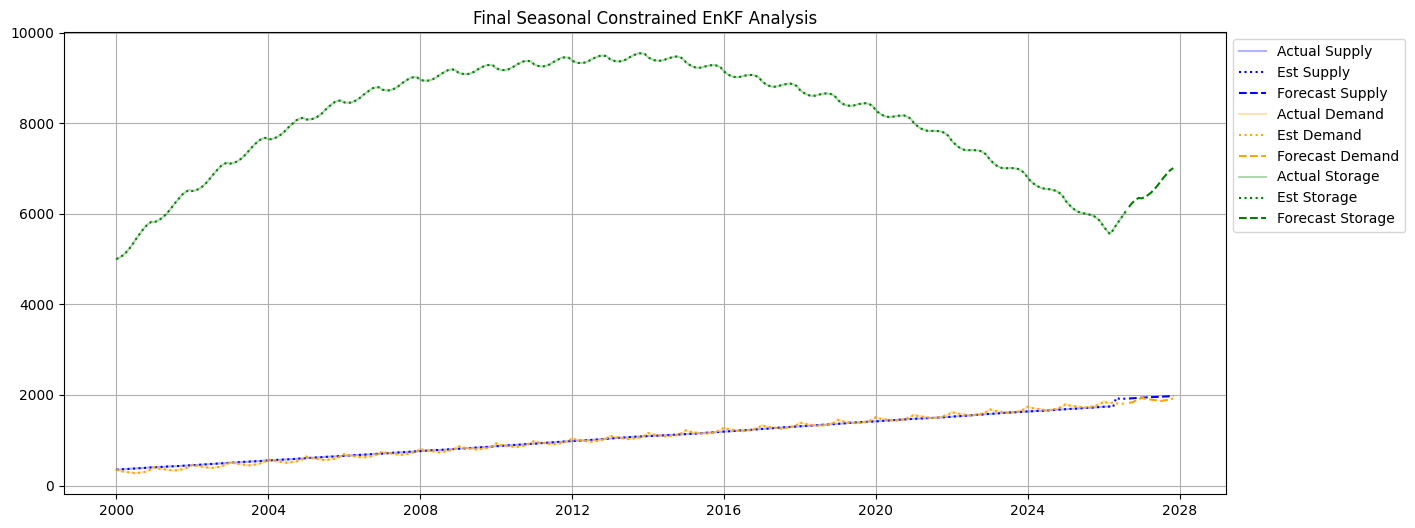

Forecasted Values (Next 15 Months):


,Supply,Demand,Storage
2026-09-01,1921.290173,1826.398477,6147.771776
2026-10-01,1925.301015,1836.438498,6237.576851
2026-11-01,1929.319789,1867.275472,6301.136723
2026-12-01,1933.545365,1886.664258,6347.517900
2027-01-01,1938.065908,1945.852801,6341.174094
2027-02-01,1942.797948,1914.922012,6367.602749
2027-03-01,1945.836260,1905.375261,6410.223627
2027-04-01,1951.023443,1896.275336,6465.451361
2027-05-01,1953.189070,1885.936116,6534.940365
2027-06-01,1956.841232,1876.278183,6617.220421


In [43]:
plt.figure(figsize=(15, 6))
for col, color in zip(data.columns, ['blue', 'orange', 'green']):
    plt.plot(data.index, data[col], label=f'Actual {col}', color=color, alpha=0.3)
    plt.plot(results_df.index, results_df[col], label=f'Est {col}', color=color, linestyle=':')
    plt.plot(forecast_df.index, forecast_df[col], label=f'Forecast {col}', color=color, linestyle='--')

plt.title("Final Seasonal Constrained EnKF Analysis")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

print("Forecasted Values (Next 15 Months):")
display(forecast_df)

In [47]:
import plotly.graph_objects as go

fig = go.Figure()
colors = {'Supply': 'blue', 'Demand': 'orange', 'Storage': 'green'}

for col in data.columns:
    # 1. Historical Actual Data - Increased opacity and weight to match forecast
    fig.add_trace(go.Scatter(
        x=data.index, y=data[col],
        name=f'Actual {col}',
        line=dict(color=colors[col], width=2),
        opacity=1.0
    ))

    # 2. Historical EnKF Estimates
    fig.add_trace(go.Scatter(
        x=results_df.index, y=results_df[col],
        name=f'Est {col}',
        line=dict(color=colors[col], width=2, dash='dot'),
        opacity=0.7
    ))

    # 3. Forecast Confidence Interval (Shaded Area)
    x_forecast = forecast_df.index.tolist()
    fig.add_trace(go.Scatter(
        x=x_forecast + x_forecast[::-1],
        y=forecast_upper[col].tolist() + forecast_lower[col].tolist()[::-1],
        fill='toself',
        fillcolor=colors[col],
        opacity=0.15,
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=False,
        name=f'{col} 95% CI'
    ))

    # 4. Forecast Mean - Adjusted to match Actual data weight
    fig.add_trace(go.Scatter(
        x=forecast_df.index, y=forecast_df[col],
        name=f'Forecast {col}',
        line=dict(color=colors[col], width=2, dash='dash'),
        opacity=1.0
    ))

fig.update_layout(
    title='Interactive EnKF Analysis (Unified Visual Weight)',
    xaxis_title='Month',
    yaxis_title='Value',
    hovermode='x unified',
    template='plotly_white',
    width=1100,
    height=700
)

fig.show()